In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read data, skipping the first 5 lines of metadata
df = pd.read_excel('../data/data.xlsx', skiprows=5, header=0)

# Rename column
df.columns = ['date', 'gold', 'silver', 'copper']


df = df[pd.to_datetime(df['date'], errors='coerce').notna()]

# Date processed
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(df.shape)
print(df.head())
print(df.dtypes)

(3157, 3)
              gold  silver   copper
date                               
2013-01-04  336.32  5967.0  57710.0
2013-01-07  338.78  6139.0  57640.0
2013-01-08  336.63  6127.0  57710.0
2013-01-09  338.91  6169.0  57640.0
2013-01-10  338.12  6154.0  57760.0
gold      float64
silver    float64
copper    float64
dtype: object


In [3]:
# Check for missing values
print("missing values：")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics：")
print(df.describe())

# Inspection period
print(f"\nstart：{df.index.min()}")
print(f"end：{df.index.max()}")
print(f"Total trading days：{len(df)}")

missing values：
gold      0
silver    0
copper    0
dtype: int64

Basic statistics：
              gold        silver         copper
count  3157.000000   3157.000000    3157.000000
mean    374.795040   4968.616725   56568.356034
std     155.409021   1858.879913   13413.495377
min     218.750000   2913.000000   33570.000000
25%     270.400000   3735.000000   47100.000000
50%     330.700000   4302.000000   51920.000000
75%     407.400000   5517.000000   68460.000000
max    1016.460000  18879.000000  100360.000000

start：2013-01-04 00:00:00
end：2025-12-31 00:00:00
Total trading days：3157


In [4]:
# log return
log_returns = np.log(df / df.shift(1)).dropna()

print("Log return：")
print(log_returns.describe())

Log return：
              gold       silver       copper
count  3156.000000  3156.000000  3156.000000
mean      0.000339     0.000356     0.000170
std       0.007995     0.014239     0.009580
min      -0.081217    -0.133180    -0.093119
25%      -0.003363    -0.005630    -0.004606
50%       0.000450     0.000217     0.000197
75%       0.004268     0.006628     0.004873
max       0.053223     0.060195     0.053467


Check the rollover issue for copper and see if there are any unusually high daily returns

In [5]:
# Identify the 10 highest absolute returns for each asset
for asset in ['gold', 'silver', 'copper']:
    print(f"\n{asset} Largest single-day fluctuation top10：")
    print(log_returns[asset].abs().nlargest(10))


gold Largest single-day fluctuation top10：
date
2013-04-16    0.081217
2020-03-24    0.053223
2013-04-15    0.051248
2020-08-12    0.050653
2016-02-15    0.046344
2025-10-09    0.045559
2025-10-22    0.043139
2016-10-10    0.040859
2013-06-21    0.038301
2020-03-13    0.037328
Name: gold, dtype: float64

silver Largest single-day fluctuation top10：
date
2020-03-17    0.133180
2025-04-07    0.088713
2013-04-16    0.088459
2016-10-10    0.073799
2021-01-11    0.069197
2020-08-12    0.066122
2020-09-23    0.065532
2013-04-15    0.062050
2020-03-13    0.061934
2013-06-21    0.061925
Name: silver, dtype: float64

copper Largest single-day fluctuation top10：
date
2020-03-19    0.093119
2020-02-03    0.061112
2025-04-07    0.057203
2016-11-11    0.053467
2013-05-02    0.048771
2021-02-22    0.048542
2017-02-13    0.046983
2014-03-10    0.045562
2015-07-08    0.045178
2020-03-23    0.042970
Name: copper, dtype: float64


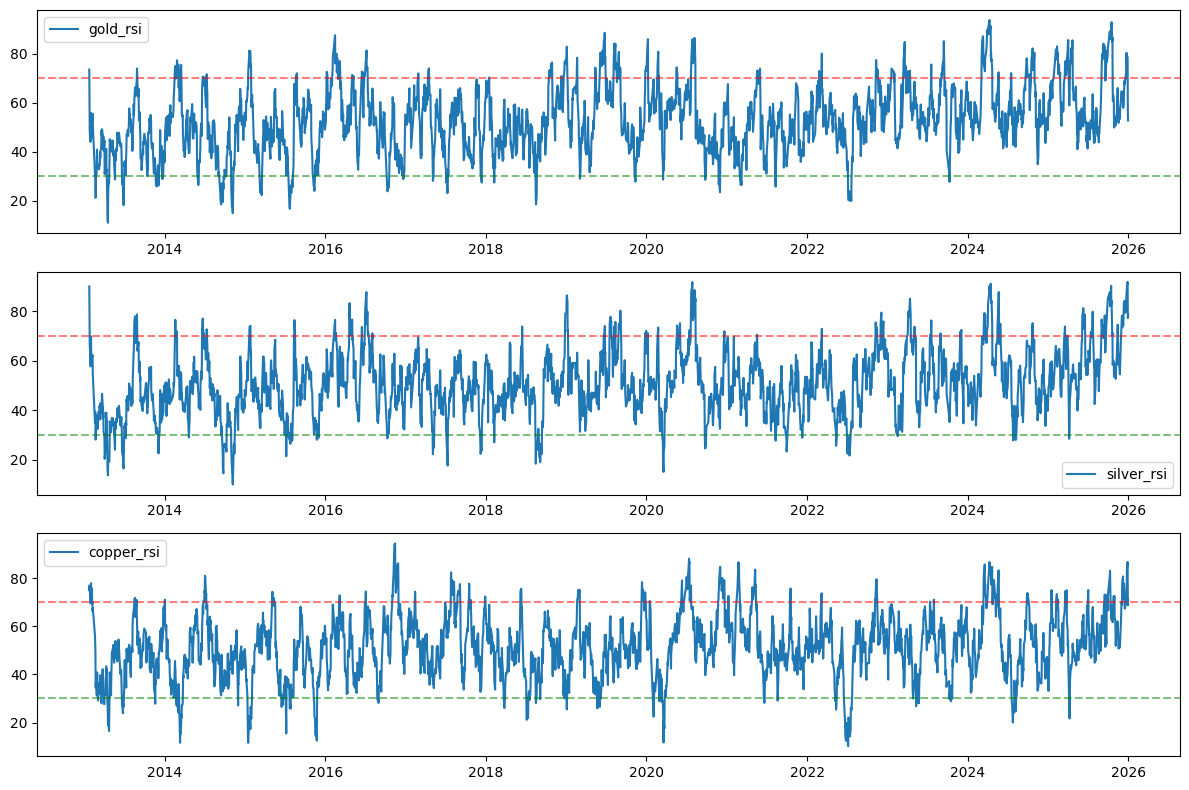

In [6]:
import ta

# 计算RSI
def compute_rsi(df, window=14):
    rsi = pd.DataFrame()
    for col in df.columns:
        rsi[f'{col}_rsi'] = ta.momentum.RSIIndicator(df[col], window=window).rsi()
    return rsi

rsi = compute_rsi(df, window=14)

# 画图看看
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, col in enumerate(['gold_rsi', 'silver_rsi', 'copper_rsi']):
    axes[i].plot(rsi[col], label=col)
    axes[i].axhline(70, color='r', linestyle='--', alpha=0.5)
    axes[i].axhline(30, color='g', linestyle='--', alpha=0.5)
    axes[i].legend()
plt.tight_layout()
plt.show()

In [7]:
import sys
sys.path.append('../')

import features.feature_engineering as fe

In [8]:
features_final = fe.build_features(df)
print(features_final.shape)
print(features_final.isnull().sum().sum())

(3078, 15)
0
